Plotting mean drag coefficient for varying Reynolds number across the three pairs of taxa

In [2]:
import parameters as par
import functions as func

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

In [3]:
Re = [100, 500, 1000, 5000, 10000]
taxa = [par.Stromatocystites, 
    par.Kailidiscus, 
    par.Helicocystis_straight, 
    par.Helicocystis,
    par.Gogia_palmeri,
    par.Gogia_spiralis
]
print(len(taxa))
Cd = np.zeros((len(taxa), len(Re)))
Cd_lower = np.zeros((len(taxa), len(Re)))
Cd_upper = np.zeros((len(taxa), len(Re)))
for i in range(len(taxa)):
    for j in range(len(Re)):
        Cd[i, j] = func.read_drag(
            taxon = taxa[i].name,
            Re = Re[j],
            flow_through_time = taxa[i].cfd["Re" + str(Re[j])]["flow_through_time"],
            write_interval = taxa[i].cfd["Re" + str(Re[j])]["write_interval"]
        )["mean"]
        Cd_lower[i, j] = func.read_drag(
            taxon = taxa[i].name,
            Re = Re[j],
            flow_through_time = taxa[i].cfd["Re" + str(Re[j])]["flow_through_time"],
            write_interval = taxa[i].cfd["Re" + str(Re[j])]["write_interval"]
        )["error"][0]
        Cd_upper[i, j] = func.read_drag(
            taxon = taxa[i].name,
            Re = Re[j], 
            flow_through_time = taxa[i].cfd["Re" + str(Re[j])]["flow_through_time"],
            write_interval = taxa[i].cfd["Re" + str(Re[j])]["write_interval"]
        )["error"][1]
taxon_names = [taxon.name for taxon in taxa]
Cd_df = pd.DataFrame(Cd, columns=Re, index=taxon_names)
Cd_df_lower = pd.DataFrame(Cd_lower, columns=Re, index=taxon_names)
Cd_df_upper = pd.DataFrame(Cd_upper, columns=Re, index=taxon_names)


6


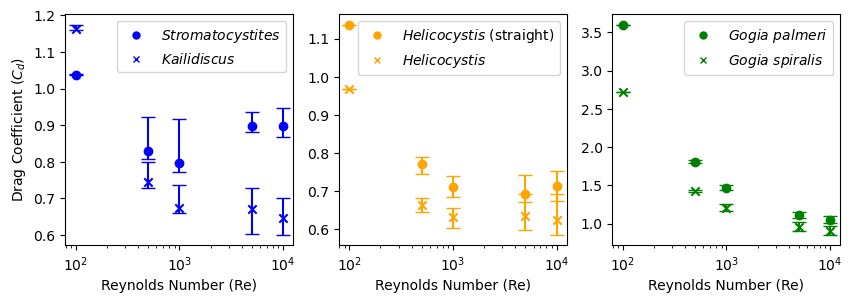

In [4]:
Re = [100, 500, 1000, 5000, 10000]
fig, axs = plt.subplots(1,3, figsize=(10, 3))

axs[0].scatter(Re, Cd_df.loc["stromatocystites"], color='blue', label='Stromatocystites')
axs[0].errorbar(Re, Cd_df.loc["stromatocystites"], yerr=[Cd_df_lower.loc["stromatocystites"], Cd_df_upper.loc["stromatocystites"]], fmt='none', color='blue', label='Drag Coefficient (Cd)',capsize=5)
axs[0].scatter(Re, Cd_df.loc["kailidiscus"], color='blue', marker= 'x', label='Kailidiscus')
axs[0].errorbar(Re, Cd_df.loc["kailidiscus"], yerr=[Cd_df_lower.loc["kailidiscus"], Cd_df_upper.loc["kailidiscus"]], fmt='none', color='blue', label='Drag Coefficient (Cd)',capsize=5)

axs[1].scatter(Re, Cd_df.loc["helicocystis_straight"], color='orange', label='Helicocystis Straight')
axs[1].errorbar(Re, Cd_df.loc["helicocystis_straight"], yerr=[Cd_df_lower.loc["helicocystis_straight"], Cd_df_upper.loc["helicocystis_straight"]], fmt='none', color='orange', label='Drag Coefficient (Cd)',capsize=5)
axs[1].scatter(Re, Cd_df.loc["helicocystis"], color='orange', marker='x', label='Helicocystis')
axs[1].errorbar(Re, Cd_df.loc["helicocystis"], yerr=[Cd_df_lower.loc["helicocystis"], Cd_df_upper.loc["helicocystis"]], fmt='none', color='orange', label='Drag Coefficient (Cd)',capsize=5)

axs[2].scatter(Re, Cd_df.loc["gogia_palmeri"], color='green', label='Gogia Palmeri')
axs[2].errorbar(Re, Cd_df.loc["gogia_palmeri"], yerr=[Cd_df_lower.loc["gogia_palmeri"], Cd_df_upper.loc["gogia_palmeri"]], fmt='none', color='green', label='Drag Coefficient (Cd)',capsize=5)
axs[2].scatter(Re, Cd_df.loc["gogia_spiralis"], color='green', marker='x', label='Gogia Spiralis')
axs[2].errorbar(Re, Cd_df.loc["gogia_spiralis"], yerr=[Cd_df_lower.loc["gogia_spiralis"], Cd_df_upper.loc["gogia_spiralis"]], fmt='none', color='green', label='Drag Coefficient (Cd)',capsize=5)

axs[0].set_xlabel("Reynolds Number (Re)")
axs[1].set_xlabel("Reynolds Number (Re)")
axs[2].set_xlabel('Reynolds Number (Re)')
axs[0].set_ylabel('Drag Coefficient' + r' ($C_d$)')
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[2].set_xscale('log')

blue_circle = mlines.Line2D([], [], color='blue', marker='o', linestyle='None',
                          markersize=5, label=par.Stromatocystites.label)
blue_cross = mlines.Line2D([], [], color='blue', marker='x', linestyle='None',
                          markersize=5, label=par.Kailidiscus.label)
orange_circle = mlines.Line2D([], [], color='orange', marker='o', linestyle='None',
                          markersize=5, label=par.Helicocystis_straight.label)
orange_cross = mlines.Line2D([], [], color='orange', marker='x', linestyle='None',
                          markersize=5, label=par.Helicocystis.label)
green_circle = mlines.Line2D([], [], color='green', marker='o', linestyle='None',
                          markersize=5, label=par.Gogia_palmeri.label)
green_cross = mlines.Line2D([], [], color='green', marker='x', linestyle='None',
                          markersize=5, label=par.Gogia_spiralis.label)

axs[0].legend(handles=[blue_circle, blue_cross])
axs[1].legend(handles=[orange_circle, orange_cross])
axs[2].legend(handles=[green_circle, green_cross])

#plt.savefig("figures/Cd.pdf", dpi=300, bbox_inches='tight')

### Conference version:

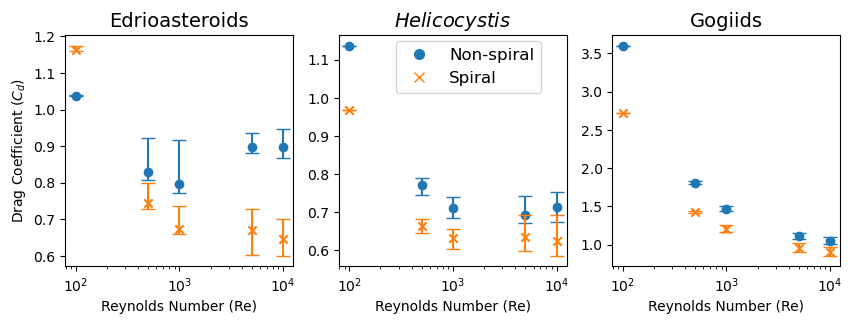

In [5]:
Re = [100, 500, 1000, 5000, 10000]
fig, axs = plt.subplots(1,3, figsize=(10, 3))

axs[0].scatter(Re, Cd_df.loc["stromatocystites"], color='C0', label='Stromatocystites')
axs[0].errorbar(Re, Cd_df.loc["stromatocystites"], yerr=[Cd_df_lower.loc["stromatocystites"], Cd_df_upper.loc["stromatocystites"]], fmt='none', color='C0', label='Drag Coefficient (Cd)',capsize=5)
axs[0].scatter(Re, Cd_df.loc["kailidiscus"], color='C1', marker= 'x', label='Kailidiscus')
axs[0].errorbar(Re, Cd_df.loc["kailidiscus"], yerr=[Cd_df_lower.loc["kailidiscus"], Cd_df_upper.loc["kailidiscus"]], fmt='none', color='C1', label='Drag Coefficient (Cd)',capsize=5)

axs[1].scatter(Re, Cd_df.loc["helicocystis_straight"], color='C0', label='Helicocystis Straight')
axs[1].errorbar(Re, Cd_df.loc["helicocystis_straight"], yerr=[Cd_df_lower.loc["helicocystis_straight"], Cd_df_upper.loc["helicocystis_straight"]], fmt='none', color='C0', label='Drag Coefficient (Cd)',capsize=5)
axs[1].scatter(Re, Cd_df.loc["helicocystis"], color='C1', marker='x', label='Helicocystis')
axs[1].errorbar(Re, Cd_df.loc["helicocystis"], yerr=[Cd_df_lower.loc["helicocystis"], Cd_df_upper.loc["helicocystis"]], fmt='none', color='C1', label='Drag Coefficient (Cd)',capsize=5)

axs[2].scatter(Re, Cd_df.loc["gogia_palmeri"], color='C0', label='Gogia Palmeri')
axs[2].errorbar(Re, Cd_df.loc["gogia_palmeri"], yerr=[Cd_df_lower.loc["gogia_palmeri"], Cd_df_upper.loc["gogia_palmeri"]], fmt='none', color='C0', label='Drag Coefficient (Cd)',capsize=5)
axs[2].scatter(Re, Cd_df.loc["gogia_spiralis"], color='C1', marker='x', label='Gogia Spiralis')
axs[2].errorbar(Re, Cd_df.loc["gogia_spiralis"], yerr=[Cd_df_lower.loc["gogia_spiralis"], Cd_df_upper.loc["gogia_spiralis"]], fmt='none', color='C1', label='Drag Coefficient (Cd)',capsize=5)

axs[0].set_xlabel("Reynolds Number (Re)")
axs[1].set_xlabel("Reynolds Number (Re)")
axs[2].set_xlabel('Reynolds Number (Re)')
axs[0].set_ylabel('Drag Coefficient' + r' ($C_d$)')
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[2].set_xscale('log')

axs[0].set_title('Edrioasteroids', fontsize=14)
axs[1].set_title(r'$\it{Helicocystis}$', fontsize=14)
axs[2].set_title('Gogiids', fontsize=14)

blue_circle = mlines.Line2D([], [], color='C0', marker='o', linestyle='None',
                          markersize=7,label='Non-spiral')
orange_cross = mlines.Line2D([], [], color='C1', marker='x', linestyle='None',
                          markersize=7, label='Spiral')

axs[1].legend(loc = [0.25, 0.75],handles=[blue_circle, orange_cross], fontsize=12)


plt.savefig("figures/Cd_conference.jpg", dpi=400, bbox_inches='tight')